In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

DATA_ABSOLUTE_PATH = "/home/angel/work/imod-internship/code/data/lifetime/commercial-qd/"

In [3]:
def read_text_file(file_path):
    # Read the text file
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Extract the column headers from the first line
    column_headers = lines[0].strip().split('\t')
    
    # Create a list to store the data
    data = []
    
    # Process each line in the text file (excluding the first line)
    for line in lines[1:]:
        # Split the line into columns using tabs as the delimiter
        columns = [int(i) for i in line.strip().split('\t')]

        # Append the columns to the data list
        data.append(columns)
    
    # Create a pandas dataframe from the data and set the column headers
    df = pd.DataFrame(data, columns=column_headers)
    
    return df

In [80]:
def plot_data(x, y, model_function, popt, legend, x_label, y_label):
    # Plots data and fitted curve using given model function
    data_line_name = legend[0]
    fit_line_name = legend[1]
    plt.plot(x, y, ".", label=data_line_name)
    plt.plot(x, model_function(x, *popt), label=fit_line_name)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    # plt.ylim([0, 1])
    plt.legend()
    plt.show()

In [81]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def fit_gaussian(x, y):
    
    p0 = [np.max(y), np.mean(x), np.std(x)]  # Initial guess for the parameters
    
    # Fit the Gaussian curve to the data
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)
    return popt, pcov

    "Time (ps)"  "Counts per bin"
0             0               597
1          1000             77120
2          2000            935716
3          3000             36188
4          4000              1484
5          5000               611
6          6000               564
7          7000               526
8          8000               467
9          9000               516
10        10000               544
11        11000               500
std is 0.417


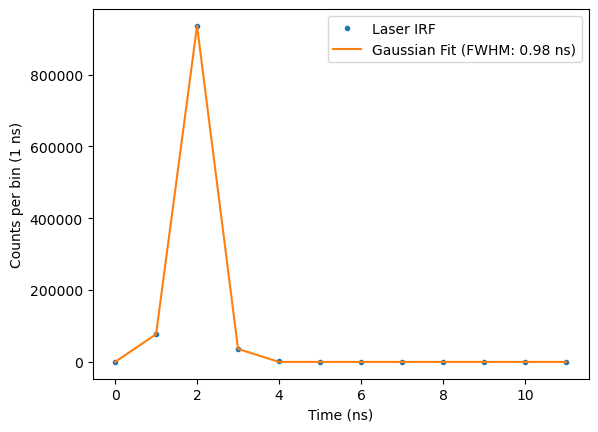

In [82]:
IRF_data_file_name_50_bins = "Histogram_2025-08-05_115039_IRF_50_superk.txt"
IRF_data_file_name_12_bins = "Histogram_2025-08-05_115233_IRF_12_superk.txt"
# df = read_text_file('2024_02_15/laser_si.txt')
# df = read_text_file('/home/angel/work/imod-internship/code/data/lifetime/tommy-lifetime/laser_si.txt') # not relevant to this notebook, disregard
df = read_text_file(f"/home/angel/work/imod-internship/code/data/lifetime/{IRF_data_file_name_12_bins}")
print(df)

x = df.values[:, 0] / 1000
y = df.values[:, 1]
popt, pcov = fit_gaussian(x, y)
print('std is %.3f' %popt[2])
fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]

legend = ["Laser IRF", f"Gaussian Fit (FWHM: {fwhm*1:.2f} ns)"]
x_label = "Time (ns)"
y_label = "Counts per bin (1 ns)"
plot_data(x, y, gaussian, popt, legend, x_label, y_label)

In [83]:
# reads in multiple files and sums the counts per bin across files
def read_multiple_text_files(file_paths):
    a = []
    b = []
    l = len(file_paths)
    # Process each file in the list 
    c = False
    for file_path in file_paths:
        d = read_text_file(file_path)
        if c == False:
            a = d.values[:, 0]/1000
            b = d.values[:, 1]
            c = True
        else:
            b += d.values[:, 1]
    return a,b,l



Text(0, 0.5, 'Counts per bin (1 ns)')

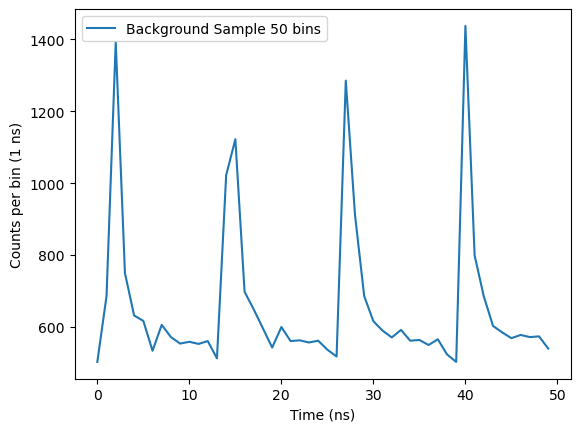

In [84]:
# for off sample (bkg)
bkg_data_file_name_50_bins = "Histogram_2025-08-05_202739_bkg_50.txt"
# times, cts, num_files = read_multiple_text_files(['/Users/tommtommbom/Desktop/qdrepos/Data/20240827/530_30_bp_in_blankspot_1.5uW.txt'])
# times, cts, num_files = read_multiple_text_files(['/home/angel/work/imod-internship/code/data/lifetime/tommy-lifetime/530_30_bp_in_blankspot_1.5uW.txt'])
times_50, cts_50, num_files_50 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{bkg_data_file_name_50_bins}"])

plt.plot(times_50, cts_50, label="Background Sample 50 bins")
plt.legend()
plt.xlabel('Time (ns)')
plt.ylabel('Counts per bin (1 ns)')

Text(0, 0.5, 'Counter per bin (1 ns)')

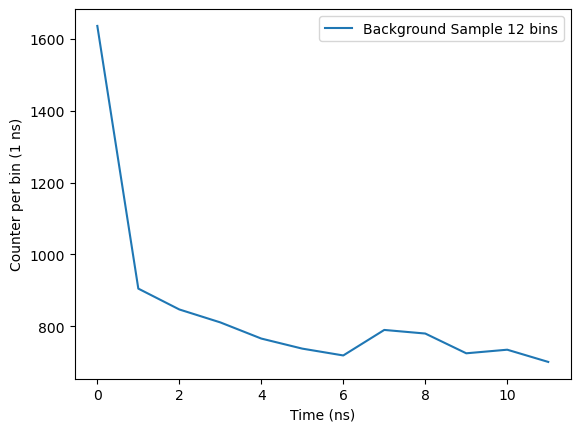

In [85]:
# off sample (bkg)
bkg_data_file_name_12_bins = "Histogram_2025-08-05_202626_bkg_12.txt"

times_12, cts_12, num_files_12 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{bkg_data_file_name_12_bins}"])

plt.plot(times_12, cts_12, label="Background Sample 12 bins")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("Counter per bin (1 ns)")

Text(0, 0.5, 'Counts per bin (1 ns)')

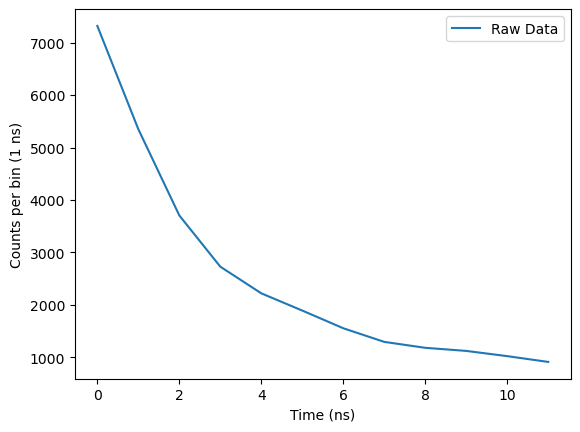

In [86]:
# dot1 = ['2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_164853.txt', '2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_170058.txt', '2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_171116.txt']
# dot2 = ['2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_182027.txt', '2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_205912.txt', '2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_211208.txt']
# dot3 = ['2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_212316.txt', '2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_213333.txt','2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_214354.txt']
# dot1 = ['/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_164853.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_170058.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_171116.txt']
# dot2 = ['/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_182027.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_205912.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_211208.txt']
# dot3 = ['/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_212316.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_213333.txt','/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_214354.txt']
data_file_name_50_bins = "Histogram_2025-08-05_202215_data_50.txt"
data_file_name_12_bins = "Histogram_2025-08-05_203152_data_12.txt"
times_nv, cts_nv, num_files_nv = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{data_file_name_12_bins}"])
plt.plot(times_nv, cts_nv, label="Raw Data")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("Counts per bin (1 ns)")

True counts: [5683 4446 2859 1918 1455 1154  836  505  402  398  288  212]
lifetime is : 2.99 ns
Second lifetime: 2.99 ns


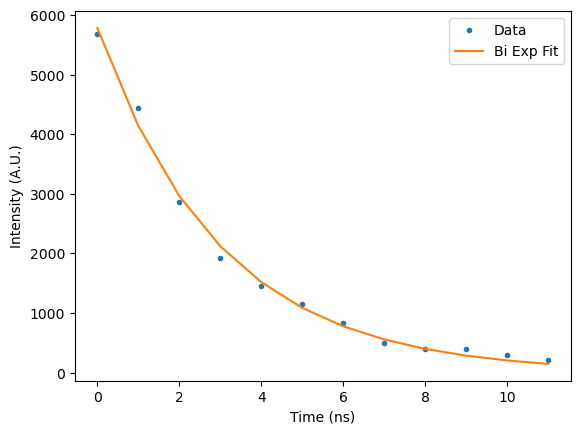

In [87]:
true_cts = cts_nv - cts_12
print(f"True counts: {true_cts}")
# true_cts = true_cts - min(true_cts) # normalize counts #PLAY WITH THIS, comment in and out to see what looks better
# true_cts = true_cts/max(true_cts) # normalize counts
from scipy import special

def expgaussian(x, a, c, f):
    std = 0.417
    arg1 = a / 2 * (2 * f + a * std**2 - 2 * x)
    arg2 = (f + a * std**2 - x) / (np.sqrt(2) * std)
    return c / 2 * np.exp(arg1) * special.erfc(arg2)
    
    # return c/2*np.exp(a/2*(2*f+a*std**2-2*x))*special.erfc((f+a*std**2-x)/(np.sqrt(2)*std)) # std obtained from fit_gaussian function call
    # https://arxiv.org/pdf/2201.03561.pdf - where math function is coming from
def fit_expgaussian(x, y):
    a0 = 2
    c0 = 1
    f0 = 0.0
    
    p0 = [a0, c0, f0]
    boundsp0 = ((0, 0, 0),(20, 100, 30))
    popt, pcov = curve_fit(expgaussian, x, y, p0=p0, maxfev=10000, gtol = 1e-10)
    
    # Plot the data and the fitted curve
    plt.plot(x, y, label='Data')
    plt.plot(x, expgaussian(x, *popt), label='ExpGaussian Fit')
    plt.xlabel('Time (ns)')
    plt.ylabel('Counts per bin (100ps)')
    plt.legend()

    # Add the FWHM to the legend
    plt.legend(['Data', 'BiExpGaussian Fit'])
    print("lifetime is: (in ns)")
    print(1/popt[0])
    print(1/popt[1])
    plt.show()
# fit_expgaussian(times_nv, true_cts) # 1.06 ns is FWHM of gaussian laser

def bi_exponential(x, amplitude_1, lifetime_1, amplitude_2, lifetime_2):
    return amplitude_1 * np.exp(-x/lifetime_1) + amplitude_2 *np.exp(-x/lifetime_2)

def fit_biexponential(x, y):
    amplitude_1_0 = 5683
    lifetime_1_0 = 10
    amplitude_2_0 = 1918
    lifetime_2_0 = 3
    p0 = [amplitude_1_0, lifetime_1_0, amplitude_2_0, lifetime_2_0]
    
    popt, pcov = curve_fit(bi_exponential, x, y, p0=p0, maxfev=10000, gtol = 1e-10)
    return popt, pcov

popt, pcov = fit_biexponential(times_nv, true_cts)
print(f"lifetime is : {popt[1]:.2f} ns")
print(f"Second lifetime: {popt[3]:.2f} ns")

legend = ["Data", "Bi Exp Fit"]
x_label = "Time (ns)"
y_label = "Intensity (A.U.)"
plot_data(times_nv, true_cts, bi_exponential, popt, legend, x_label, y_label)